In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random
import os

In [2]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path("../data/filtered") / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"])
print("Loaded:", data_file)

Loaded: ..\data\filtered\youtube_static.csv


In [3]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [4]:
df = df.rename(columns={
    'ue_ident': 'item_id',
    'DATE': 'timestamp',
    'mac_dl_brate': 'target'
})

target_df = df[['item_id', 'timestamp', 'target']]
uni_data = TimeSeriesDataFrame(target_df)
uni_data.head()

target
item_id timestamp                       
2105    2022-01-01 00:00:00.000  4311377
        2022-01-01 00:00:00.001  3688977
        2022-01-01 00:00:00.002  3832977
        2022-01-01 00:00:00.003  3089955
        2022-01-01 00:00:00.004  4654044

In [5]:
prediction_length = 96

train_size = int(len(df) * 0.8)
train_data = uni_data.iloc[:train_size]
test_data = uni_data.iloc[train_size:]


predictor = TimeSeriesPredictor(prediction_length=prediction_length, freq='ms').fit(
    train_data, presets="bolt_small",
)

Beginning AutoGluon training...


AutoGluon will save models to 'C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\Reproducibility\notebooks\AutogluonModels\ag-20260616_082015'


=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
GPU Count:          0
Memory Avail:       18.81 GB / 31.73 GB (59.3%)
Disk Space Avail:   205.46 GB / 475.70 GB (43.2%)


Setting presets to: bolt_small



Fitting with arguments:


...

Training timeseries model Chronos[bolt_small]. 


	42.32   s     = Training runtime


Training complete. Models trained: ['Chronos[bolt_small]']


Total runtime: 42.49 s


Best model: Chronos[bolt_small]


In [6]:
def rolling_chronos_forecast_all(predictor, test_data, prediction_length=96, stride=1, measure_time=False):
    results = []
    times = []

    test_data = test_data.copy()
    if not isinstance(test_data.index, pd.MultiIndex):
        raise ValueError("Expected test_data with MultiIndex (item_id, timestamp).")

    for item_id, series in test_data.groupby(level="item_id"):
        series = series.reset_index()  

        for start in range(0, len(series) - prediction_length, stride):
            context = series.iloc[: start + prediction_length]

            t0 = time.time()
            forecast = predictor.predict(context.set_index(["item_id", "timestamp"]))
            t1 = time.time()

            if measure_time:
                times.append(t1 - t0)

            forecast_mean = forecast.loc[item_id]["mean"].to_numpy().flatten()
            origin_ts = series["timestamp"].iloc[start]  
            forecast_ts = pd.date_range(start=origin_ts + pd.Timedelta(milliseconds=1),
                                        periods=prediction_length,
                                        freq="ms")

            df_forecast = pd.DataFrame({
                "item_id": item_id,
                "timestamp": forecast_ts,
                "mean": forecast_mean
            })
            results.append(df_forecast)

    forecasts_df = pd.concat(results, ignore_index=True)
    return (forecasts_df, times) if measure_time else forecasts_df


In [7]:
rolling_preds, times = rolling_chronos_forecast_all(
    predictor, test_data, prediction_length=96, stride=1, measure_time=True
)

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


...

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]


In [8]:
actual = test_data.reset_index()[["item_id", "timestamp", "target"]]

aligned = rolling_preds.merge(
    actual, on=["item_id", "timestamp"], how="inner"
)

In [9]:
scaler = MinMaxScaler()
scaler.fit(train_data.reset_index()[["target"]])  

aligned["mean_scaled"] = scaler.transform(aligned[["mean"]].to_numpy())
aligned["target_scaled"] = scaler.transform(aligned[["target"]].to_numpy())

rmse_scaled = np.sqrt(mean_squared_error(aligned["target_scaled"], aligned["mean_scaled"]))
mae_scaled = mean_absolute_error(aligned["target_scaled"], aligned["mean_scaled"])

print(f"Scaled RMSE: {rmse_scaled:.4f}")
print(f"Scaled MAE: {mae_scaled:.4f}")


Scaled RMSE: 0.0312
Scaled MAE: 0.0185


c:\Users\EJ17UF\AppData\Local\anaconda3\envs\chronos-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\EJ17UF\AppData\Local\anaconda3\envs\chronos-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [10]:
def block_average(df, value_col, item_col="item_id", timestamp_col="timestamp", block_len=96):
    df = df.sort_values([item_col, timestamp_col]).reset_index(drop=True)
    results = []

    for item_id, group in df.groupby(item_col):
        y = group[value_col].to_numpy()
        ts = group[timestamp_col].to_numpy()

        num_blocks = len(y) // block_len
        if num_blocks == 0:
            continue

        y_trunc = y[:num_blocks*block_len].reshape(num_blocks, block_len)
        ts_trunc = ts[:num_blocks*block_len].reshape(num_blocks, block_len)

        results.append(pd.DataFrame({
            item_col: item_id,
            "block_id": np.arange(num_blocks),
            "value_avg": y_trunc.mean(axis=1),
            "timestamp_mid": ts_trunc[:, block_len // 2]  
        }))

    return pd.concat(results, ignore_index=True)


In [11]:
actual_blocked = block_average(aligned, value_col="target", block_len=prediction_length)
pred_blocked = block_average(aligned, value_col="mean", block_len=prediction_length)

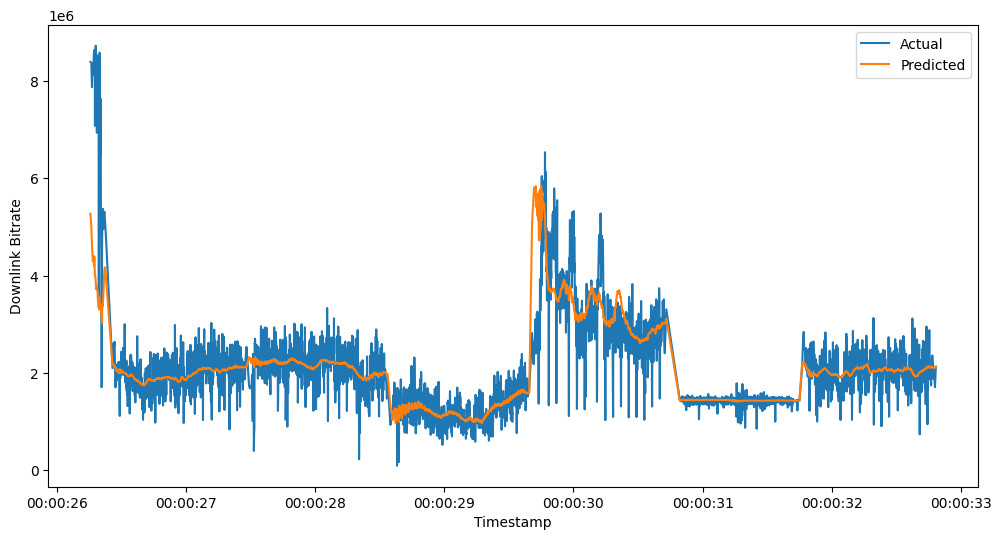

In [12]:
plt.figure(figsize=(12,6))
plt.plot(actual_blocked['timestamp_mid'], actual_blocked['value_avg'], label='Actual')
plt.plot(pred_blocked['timestamp_mid'], pred_blocked['value_avg'], label='Predicted')
plt.xlabel("Timestamp")
plt.ylabel("Downlink Bitrate")
plt.legend()
plt.show()


In [13]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "Chronos-Zeroshot",
    "setting": "univariate",
    "dataset": "youtube_static",
    "rmse": rmse_scaled,
    "mae": mae_scaled,
}])

metrics_file = results_dir / "chronoszs_uni_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\chronoszs_uni_metrics.csv
